# Plan d'expérience général

## Conditions du plan d'expérience

Le plan d'expérience général nous servira à définir le meilleur algorithme qui minimise la fonction objectif : 
$$\text{min Z} = \sum_{u=0}^{n} \sum_{v=0}^{n} P(u,v) ⋅ x_{(u,v)}$$

respectant ces contraintes : 
$$x_{u,v} = 0 \ \forall(u,v) \in E \text{ tel que } P(u,v) = -1$$
$$t_u < t_v ∀(u,v) \in D$$


À partir des sous-plans d'expériences réalisés en amont, nous avons pour chaque algorithme récupéré ces paramètres:

- `ant_system`: 
    - `alpha` = 0.07
    - `beta` = 1.7
    - `evaporation_rate` = 0.5
    - `initial_pheromone` = 1.5
- `genetic`:
    - `population_size` = 50
    - `crossover_rate` = 1.00
    - `mutation_rate` = 0.50
    - `tournament_size` = 5
    - `elite_size` = 2
- `hcms_system`:
    - `iterations` = 50
- `nearest_neighbor`:
    - `multi_start` = True
- `recuit_simule_ms`:
    - `n_restarts` = 5
    - `max_iter_per_restart` = 5000
    - `alpha` = 0.995
- `recuit_simule`:
    - `α` = 0.999
    - `max_iter` = 10 000
- `tabu_search_with_2opt`:
    - `n_iterations` = 200
    - `tabu_tenure` = 7
- `tabu_search`:
    - `n_iterations` = 200
    - `tabu_tenure` = 10

In [34]:
import sys
import warnings

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

sys.path.insert(0, "../../")
sys.path.insert(0, "../")

warnings.filterwarnings("ignore")

from graph_generator import generate_graph
from src.algorithms.ant_system import resolve_by_ant_system
from src.algorithms.genetic import resolve_by_genetic
from src.algorithms.hill_climbing_ms import resolve_by_ms_hill_climbing
from src.algorithms.nearest_neighbor import resolve_by_nearest_neighbor
from src.algorithms.recuit_simule import resolve_by_recuit_simule, resolve_by_ms_recuit_simule
from src.algorithms.tabu_search_2opt import resolve_by_tabu_search_with_2opt
from src.algorithms.tabu_search import resolve_by_tabu_search

In [35]:
NB_SEEDS: int = 15
MAX_VALID_COST: float = 1_000_000.0

ALL_N_VALUES: list[int] = [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000]

# Per-algo N range — slow algos capped at lower N
ALGO_N_VALUES: dict[str, list[int]] = {
    "Nearest Neighbor":  [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000],
    "Tabu Search 2-opt": [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500],
    "Recuit Simulé":     [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400],
    "Recuit Simulé MS":  [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400],
    "Genetic":           [5, 10, 15, 20, 25, 30, 40, 50],
    "Tabu Search":       [5, 10, 15, 20, 25, 30, 40, 50],
    "Ant System":        [5, 10, 15, 20, 25, 30],
    "HCMS":              [5, 10, 15, 20, 25, 30],
}


def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            if not graph.has_edge(v, u):
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, ref: float) -> float:
    if ref <= 0 or cost == float("inf"):
        return float("nan")
    return 100.0 * (cost - ref) / ref


def get_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph, float]]:
    result: list[tuple[int, nx.Graph, float]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        ref = reference_value(graph)
        result.append((seed, graph, ref))
    return result

In [36]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in ALL_N_VALUES:
    instances[n] = get_instances(n)
    print(f"N={n:3d} — {len(instances[n])} instances générées")

N=  5 — 15 instances générées
N= 10 — 15 instances générées
N= 15 — 15 instances générées
N= 20 — 15 instances générées
N= 25 — 15 instances générées
N= 30 — 15 instances générées
N= 40 — 15 instances générées
N= 50 — 15 instances générées
N= 60 — 15 instances générées
N= 75 — 15 instances générées
N=100 — 15 instances générées
N=125 — 15 instances générées
N=150 — 15 instances générées
N=175 — 15 instances générées
N=200 — 15 instances générées
N=250 — 15 instances générées
N=300 — 15 instances générées
N=400 — 15 instances générées
N=500 — 15 instances générées
N=750 — 15 instances générées
N=1000 — 15 instances générées


In [37]:
ALGO_SEED: int = 42

ALGORITHMS: dict[str, callable] = {
    "Nearest Neighbor": lambda g: resolve_by_nearest_neighbor(
        g,
        multi_start=True,
    ),
    "Tabu Search 2-opt": lambda g: resolve_by_tabu_search_with_2opt(
        g,
        n_iterations=500,
        tabu_tenure=7,
    ),
    "Recuit Simulé": lambda g: resolve_by_recuit_simule(
        g,
        max_iterations=10000,
        alpha=0.999,
        seed=ALGO_SEED,
    ),
    "Recuit Simulé MS": lambda g: resolve_by_ms_recuit_simule(
        g,
        n_restarts=5,
        max_iterations_per_restart=3000,
        alpha=0.995,
        seed=ALGO_SEED,
    ),
    "Genetic": lambda g: resolve_by_genetic(
        g,
        generations=1000,
        population_size=50,
        crossover_rate=1.00,
        mutation_rate=0.50,
        tournament_size=5,
        elite_size=2,
    ),
    "Tabu Search": lambda g: resolve_by_tabu_search(
        g,
        n_iterations=500,
        tabu_tenure=10,
    ),
    "Ant System": lambda g: resolve_by_ant_system(
        g,
        n_iterations=1000,
        alpha=0.07,
        beta=1.7,
        evaporation_rate=0.5,
        initial_pheromone=1.5,
    ),
    "HCMS": lambda g: resolve_by_ms_hill_climbing(
        g,
        iterations=100,
    ),
}

records: list[dict] = []

for algo_name, algo_fn in ALGORITHMS.items():
    n_values = ALGO_N_VALUES[algo_name]
    print(f"\n▶ {algo_name}  (N jusqu'à {max(n_values)})")
    for n in n_values:
        gaps: list[float] = []
        n_invalid: int = 0
        for seed, graph, ref in instances[n]:
            np.random.seed(ALGO_SEED)
            try:
                _, cost = algo_fn(graph)
            except Exception:
                cost = float("inf")
            if cost > MAX_VALID_COST:
                n_invalid += 1
                continue
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
        mean_gap = np.mean(gaps) if gaps else float("nan")
        std_gap = np.std(gaps) if gaps else float("nan")
        records.append({"Algorithme": algo_name, "N": n, "gap_mean": mean_gap, "gap_std": std_gap})
        invalid_note = f" | {n_invalid} invalides ignorés" if n_invalid else ""
        print(f"  N={n:3d} → gap moyen = {mean_gap:.2f}%  (±{std_gap:.2f}){invalid_note}")

df_results = pd.DataFrame(records)


▶ Nearest Neighbor  (N jusqu'à 1000)
  N=  5 → gap moyen = 448.55%  (±335.44) | 1 invalides ignorés
  N= 10 → gap moyen = 311.58%  (±95.91)
  N= 15 → gap moyen = 346.72%  (±113.32)
  N= 20 → gap moyen = 378.07%  (±83.83)
  N= 25 → gap moyen = 429.40%  (±92.86)
  N= 30 → gap moyen = 409.29%  (±69.60)
  N= 40 → gap moyen = 459.95%  (±91.65)
  N= 50 → gap moyen = 473.35%  (±55.65)
  N= 60 → gap moyen = 486.48%  (±56.76)
  N= 75 → gap moyen = 500.42%  (±62.78)
  N=100 → gap moyen = 486.70%  (±55.77)
  N=125 → gap moyen = 479.91%  (±46.82)
  N=150 → gap moyen = 456.20%  (±50.49)
  N=175 → gap moyen = 436.70%  (±26.18)
  N=200 → gap moyen = 432.50%  (±40.19)
  N=250 → gap moyen = 384.31%  (±30.32)
  N=300 → gap moyen = 364.34%  (±22.04)
  N=400 → gap moyen = 313.12%  (±13.93)
  N=500 → gap moyen = 283.55%  (±22.25)
  N=750 → gap moyen = 225.61%  (±6.96)
  N=1000 → gap moyen = 191.58%  (±5.97)

▶ Tabu Search 2-opt  (N jusqu'à 500)
  N=  5 → gap moyen = 345.95%  (±166.73) | 1 invalides ignoré

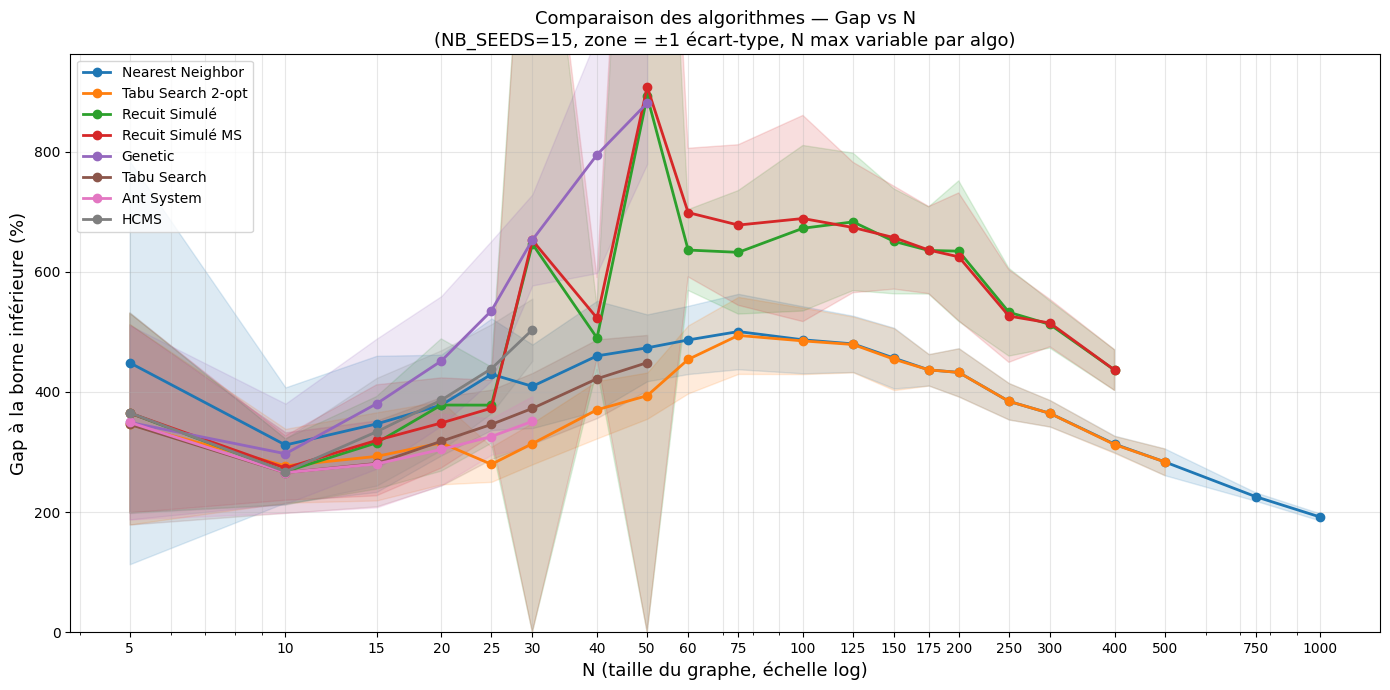

In [40]:
fig, ax = plt.subplots(figsize=(14, 7))

colors = cm.tab10.colors
algo_names = list(ALGORITHMS.keys())

all_means: list[float] = []

for i, algo_name in enumerate(algo_names):
    sub = df_results[df_results["Algorithme"] == algo_name].sort_values("N")
    ns = sub["N"].values
    means = sub["gap_mean"].values
    stds = sub["gap_std"].values
    color = colors[i % len(colors)]

    valid = np.isfinite(means) & np.isfinite(stds)
    if valid.sum() == 0:
        print(f"[SKIP] {algo_name} — aucun résultat valide")
        continue
    if valid.sum() < len(ns):
        skipped = ns[~valid].tolist()
        print(f"[WARN] {algo_name} — N={skipped} ignorés (aucune solution trouvée)")

    all_means.extend(means[valid].tolist())
    ax.plot(ns[valid], means[valid], marker="o", linewidth=2, label=algo_name, color=color)
    ax.fill_between(
        ns[valid],
        np.maximum(means[valid] - stds[valid], 0),
        means[valid] + stds[valid],
        alpha=0.15,
        color=color,
    )

if all_means:
    y_cap = np.percentile(all_means, 95) * 1.4
    ax.set_ylim(bottom=0, top=y_cap)

ax.set_xscale("log")
ax.set_xticks(ALL_N_VALUES)
ax.set_xticklabels([str(n) for n in ALL_N_VALUES])
ax.set_xlabel("N (taille du graphe, échelle log)", fontsize=13)
ax.set_ylabel("Gap à la borne inférieure (%)", fontsize=13)
ax.set_title(
    f"Comparaison des algorithmes — Gap vs N\n"
    f"(NB_SEEDS={NB_SEEDS}, zone = ±1 écart-type, N max variable par algo)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## Interprétation 
Le graphe compare le gap à la borne inférieure de plusieurs algorithmes TSP en fonction de la taille du graphe N, sur 15 seeds. Plus le gap est bas, meilleur est l'algorithme.

Premier constat : tous les algorithmes sont très loin de la borne inférieure, entre 200% et 900%. Soit la borne est très lâche, soit les algorithmes sont mal calibrés. À vérifier en priorité.

À petite taille (N < 20), les algorithmes sont indistinguables car la variance est énorme. Les bandes de confiance se chevauchent toutes. 15 seeds ne suffisent pas pour tirer des conclusions à ce régime.

Le spike à N=50 est anormal. Recuit Simulé MS monte à ~900%, Recuit Simulé et Genetic suivent. C'est probablement un artefact : hyperparamètres mal calibrés pour cette taille, ou une seed particulièrement pathologique. À investiguer.

À grande taille (N > 100), deux tendances se dégagent. Nearest Neighbor et Tabu Search 2-opt améliorent leur gap relatif en descendant vers 200-280% à N=1000. Les Recuit Simulé stagnent autour de 600%. Genetic, Ant System et HCMS disparaissent du graphe dès N=75-200, ils ne scalent pas.

Le point le plus contre-intuitif : Nearest Neighbor bat Recuit Simulé à grand N. L'explication probable est que le budget de temps est fixe, donc Recuit fait proportionnellement moins d'itérations sur un grand graphe, ce qui rend l'exploration insuffisante.

Conclusion générale : Tabu Search 2-opt est le meilleur compromis sur toute la plage. Recuit Simulé MS n'apporte rien par rapport à Recuit simple. Le spike à N=50 mérite une investigation avant de tirer des conclusions sur ces deux variantes.

In [39]:
table = df_results.pivot(index="N", columns="Algorithme", values="gap_mean")
table.columns.name = None
table.index.name = "N"

ordered_cols = [c for c in list(ALGORITHMS.keys()) if c in table.columns]
table = table[ordered_cols].round(2)

try:
    display(
        table.style
        .background_gradient(cmap="RdYlGn_r", axis=1)
        .set_caption(f"Gap moyen (%) par algorithme et par N — {NB_SEEDS} instances/N (— = algo non évalué à ce N)")
        .format("{:.2f}", na_rep="—")
    )
except AttributeError:
    display(table)

,Nearest Neighbor,Tabu Search 2-opt,Recuit Simulé,Recuit Simulé MS,Genetic,Tabu Search,Ant System,HCMS
N,,,,,,,,
5,448.55,345.95,364.88,364.88,349.26,345.95,349.26,365.37
10,311.58,277.01,267.28,273.24,297.07,265.63,265.63,267.28
15,346.72,292.65,315.22,319.37,380.32,280.92,280.06,333.64
20,378.07,315.22,378.13,348.23,451.47,317.83,304.23,386.34
25,429.40,279.50,377.98,372.86,535.06,345.88,325.74,438.60
30,409.29,313.90,646.28,652.35,652.96,372.53,350.93,503.50
40,459.95,370.28,489.70,522.84,794.73,421.92,NaN,NaN
50,473.35,393.71,892.01,907.76,880.79,448.70,NaN,NaN
60,486.48,454.09,636.12,698.45,NaN,NaN,NaN,NaN
